# DASHBOARD DEVELOPMENT

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

plt.style.use("seaborn-v0_8")

In [2]:
df = pd.read_csv("../data/processed/cleaned_data.csv")
clustered_df = pd.read_csv("../results/tables/clustering_results.csv")
cluster_summary = pd.read_csv("../results/tables/cluster_summary.csv")

df.head()

,Age,HighBP,HighChol,Stroke,HeartDiseaseorAttack,BMI,Smoker,HvyAlcoholConsump,PhysActivity,Fruits,Veggies,Diabetes_012,ComorbidityScore,AgeGroup,LifestyleScore,HealthBurden
0,9,1,1,0,0,40,1,0,0,0,1,0,2,60-64,3,9.0
1,7,0,0,0,0,25,1,0,1,0,0,0,0,50-54,3,5.5
2,9,1,1,0,0,28,0,0,0,1,0,0,2,60-64,2,6.8
3,11,1,0,0,0,27,0,0,1,1,1,0,1,70-74,0,3.7
4,11,1,1,0,0,24,0,0,1,1,1,0,2,70-74,0,4.4


In [3]:
diseases = ['HighBP', 'HighChol', 'Stroke', 'HeartDiseaseorAttack']
prevalence = df[diseases].mean().sort_values(ascending=False)

prevalence

HighBP                  0.454441
HighChol                0.441760
HeartDiseaseorAttack    0.103216
Stroke                  0.044756
dtype: float64

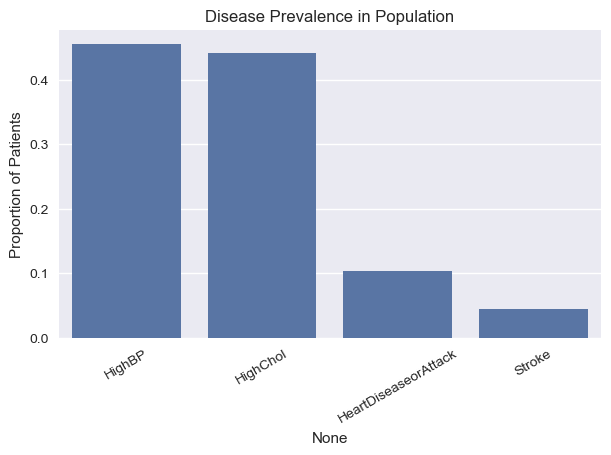

In [4]:
plt.figure(figsize=(7,4))
sns.barplot(x=prevalence.index, y=prevalence.values)
plt.title("Disease Prevalence in Population")
plt.ylabel("Proportion of Patients")
plt.xticks(rotation=30)
plt.show()

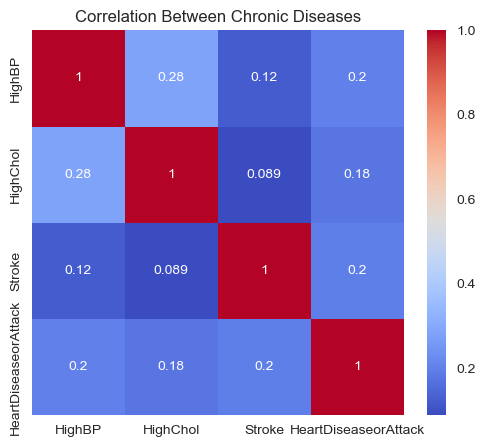

In [5]:
plt.figure(figsize=(6,5))
sns.heatmap(df[diseases].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Chronic Diseases")
plt.show()

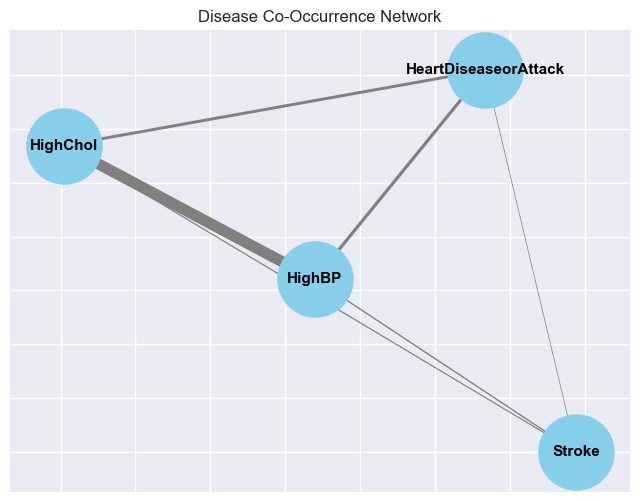

In [6]:
co_matrix = df[diseases].T.dot(df[diseases])

G = nx.Graph()
for i in co_matrix.index:
    for j in co_matrix.columns:
        if i != j:
            G.add_edge(i, j, weight=co_matrix.loc[i, j])

plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42)

edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]
norm_weights = [w / max(weights) * 8 for w in weights]

nx.draw_networkx_nodes(G, pos, node_size=3000, node_color="skyblue")
nx.draw_networkx_labels(G, pos, font_size=11, font_weight="bold")
nx.draw_networkx_edges(G, pos, width=norm_weights, edge_color="gray")

plt.title("Disease Co-Occurrence Network")
plt.show()

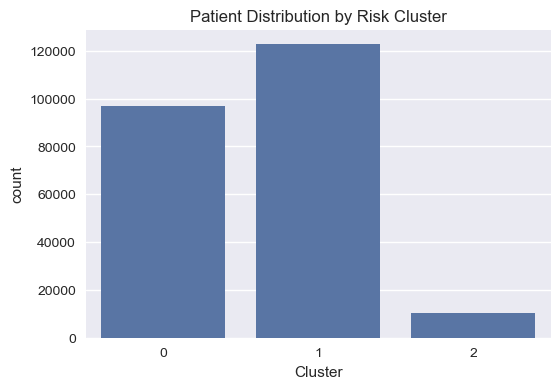

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='Cluster', data=clustered_df)
plt.title("Patient Distribution by Risk Cluster")
plt.show()

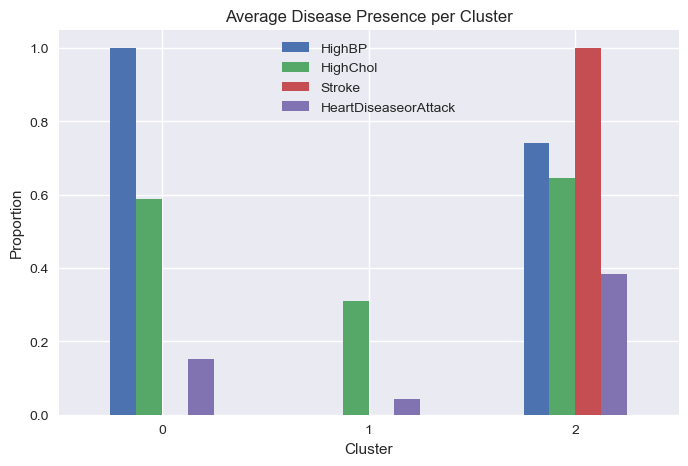

In [8]:
cluster_summary.set_index('Cluster', inplace=True)

cluster_summary.plot(kind='bar', figsize=(8,5))
plt.title("Average Disease Presence per Cluster")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()

In [9]:
rules = pd.read_csv("../results/tables/association_rules.csv")
rules.head()

,antecedents,consequents,support,confidence,lift
0,"HeartDiseaseorAttack, HighBP","Stroke, HighChol",0.010802,0.139564,4.823143
1,"Stroke, HighChol","HeartDiseaseorAttack, HighBP",0.010802,0.373289,4.823143
2,"HighBP, Stroke","HeartDiseaseorAttack, HighChol",0.010802,0.325850,4.511307
3,"HeartDiseaseorAttack, HighChol","HighBP, Stroke",0.010802,0.149545,4.511307
4,HeartDiseaseorAttack,"HighBP, Stroke, HighChol",0.010802,0.104651,4.416297


### Final Dashboard Summary

The dashboard consolidates all project insights into an interpretable visual format.
Key highlights include:

- HighBP and HighChol are the most prevalent and influential chronic diseases.
- Disease network analysis reveals a tightly connected cardiovascular cluster.
- Association rules identify combinations that significantly increase disease risk.
- Clustering separates patients into low, medium, and high-risk groups.
- The dashboard enables non-technical users to explore comorbidity patterns interactively.